In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
import pickle
from astropy.io import fits 
%matplotlib widget 

In [2]:
plt.rcParams['font.family'] = 'DejaVu Sans Mono'   # Replace 'DejaVu Sans Mono', DejaVu Serif with your preferred font
plt.rcParams['font.size'] = 12          # Set font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 14     # Axes label font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size
plt.rcParams['xtick.labelsize'] = 10    # X-axis tick font size
plt.rcParams['ytick.labelsize'] = 10    # Y-axis tick font size

In [3]:
science_list = np.genfromtxt('./group15_WASP-12_20191229/science/science.list', dtype=str)
science_temp_list = science_list[:10]

science_corrected = pickle.load(open('./group15_WASP-12_20191229/correct/' + science_temp_list[5][:-5] + '_corr.p','rb'))
science_corrected_err = pickle.load(open('./group15_WASP-12_20191229/correct/' + science_temp_list[5][:-5] + '_corr_errors.p','rb'))

In [4]:
x_target_refined = 357.00
y_target_refined = 37.64

x_reference_01_refined = 172.21
y_reference_01_refined = 186.39

x_reference_02_refined = 471.12
y_reference_02_refined = 90.58

# Computing again the meshgrid arrays 
ylen, xlen = np.shape(science_corrected)
X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

# 2D array with the distance of each pixel from the target star 
target_distance = np.sqrt((X-x_target_refined)**2 + (Y-y_target_refined)**2)
reference_01_distance = np.sqrt((X-x_reference_01_refined)**2 + (Y-y_reference_01_refined)**2)
reference_02_distance = np.sqrt((X-x_reference_02_refined)**2 + (Y-y_reference_02_refined)**2)

In [5]:
def make_circle_around_star(x_pos, y_pos, radius, thickness=0.5, label='', color='w', alpha=1.):

    n, radii = 50, [radius, radius+thickness]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=alpha, label=label)

vmin: 860.5    vmax: 1721.1


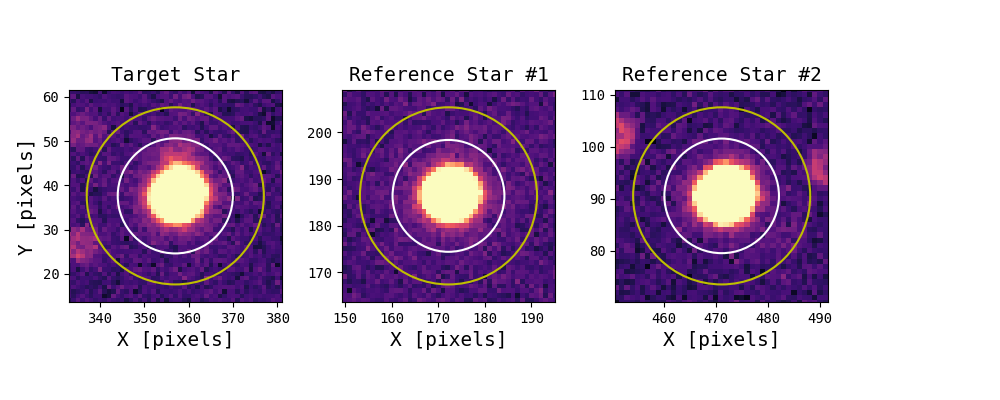

In [6]:
# Values for the inner and outer radii of the target and reference stars
target_inner_radius = 13
target_outer_radius = 20

reference_01_inner_radius = 12
reference_01_outer_radius = 19

reference_02_inner_radius = 11
reference_02_outer_radius = 17

from matplotlib import colors

# Calculate vmin and vmax for the color scale
vmin = np.amin(science_corrected[:, 100:400])
vmax = np.amax(science_corrected[:, 100:400])

vmax = 2 * vmin
print(f'vmin: {vmin:.1f}    vmax: {vmax:.1f}')

# Create a 1x3 grid of subplots
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# Function to create circles around a star
def make_circle_around_star(ax, x_pos, y_pos, radius, color='w', label=''):
    from matplotlib.patches import Circle

    circle = Circle((x_pos, y_pos), radius, edgecolor=color, facecolor='none', label=label, lw=1.5)
    ax.add_patch(circle)

# Plot the target star in ax[0]
im = ax[0].imshow(
    science_corrected,
    cmap=plt.colormaps['magma'],
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    origin='lower'
)

ax[0].set_xlim(x_target_refined - target_outer_radius * 1.2, x_target_refined + target_outer_radius * 1.2)
ax[0].set_ylim(y_target_refined - target_outer_radius * 1.2, y_target_refined + target_outer_radius * 1.2)
make_circle_around_star(ax[0], x_target_refined, y_target_refined, target_inner_radius, color='w', label='Inner Radius')
make_circle_around_star(ax[0], x_target_refined, y_target_refined, target_outer_radius, color='y', label='Outer Radius')
ax[0].set_title('Target Star')
ax[0].set_xlabel('X [pixels]')
ax[0].set_ylabel('Y [pixels]')
#ax[0].legend(loc='upper left')

# Plot reference star 1 in ax[1]
ax[1].imshow(
    science_corrected,
    cmap=plt.colormaps['magma'],
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    origin='lower'
)

ax[1].set_xlim(x_reference_01_refined - reference_01_outer_radius * 1.2, x_reference_01_refined + reference_01_outer_radius * 1.2)
ax[1].set_ylim(y_reference_01_refined - reference_01_outer_radius * 1.2, y_reference_01_refined + reference_01_outer_radius * 1.2)
make_circle_around_star(ax[1], x_reference_01_refined, y_reference_01_refined, reference_01_inner_radius, color='w', label='Inner Radius')
make_circle_around_star(ax[1], x_reference_01_refined, y_reference_01_refined, reference_01_outer_radius, color='y', label='Outer Radius')
ax[1].set_title('Reference Star #1')
ax[1].set_xlabel('X [pixels]')
#ax[1].legend(loc='upper left')

# Plot reference star 2 in ax[2]
ax[2].imshow(
    science_corrected,
    cmap=plt.colormaps['magma'],
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    origin='lower'
)

ax[2].set_xlim(x_reference_02_refined - reference_02_outer_radius * 1.2, x_reference_02_refined + reference_02_outer_radius * 1.2)
ax[2].set_ylim(y_reference_02_refined - reference_02_outer_radius * 1.2, y_reference_02_refined + reference_02_outer_radius * 1.2)
make_circle_around_star(ax[2], x_reference_02_refined, y_reference_02_refined, reference_02_inner_radius, color='w', label='Inner Radius')
make_circle_around_star(ax[2], x_reference_02_refined, y_reference_02_refined, reference_02_outer_radius, color='y', label='Outer Radius')
ax[2].set_title('Reference Star #2')
ax[2].set_xlabel('X [pixels]')
#ax[2].legend(loc='upper left')
#cbar = fig.colorbar(im, ax=ax, location='right', fraction=0.05, pad=0.2)
#cbar.set_label('Intensity')
# Show the plot
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [7]:
target_distance = np.sqrt((X-x_target_refined)**2 + (Y-y_target_refined)**2)
target_annulus_selection = (target_distance > target_inner_radius) & (target_distance<=target_outer_radius)

target_sky_flux_error = np.sqrt( np.sum(science_corrected_err[target_annulus_selection]**2) ) / np.sum(target_annulus_selection)
target_sky_flux_average = np.sum(science_corrected[target_annulus_selection]) / np.sum(target_annulus_selection)
target_sky_flux_median = np.median(science_corrected[target_annulus_selection])
target_science_sky_corrected = science_corrected - target_sky_flux_average
target_science_sky_corrected_error = np.sqrt(science_corrected_err**2 + target_sky_flux_error**2)
print('target')
print('Sky flux error (example): {0:7.1f} photons/pixel'.format(target_sky_flux_error))
print('Number of pixels included in the annulus: {0:7.0f}'.format(np.sum(target_annulus_selection)))
print('Average Sky flux: {0:7.1f} photons/pixel'.format(target_sky_flux_average)) 
print('Median Sky flux: {0:7.1f} photons/pixel'.format(target_sky_flux_median))
print('-------') 
print('ref01')
reference_01_distance = np.sqrt((X-x_reference_01_refined)**2 + (Y-y_reference_01_refined)**2)
reference_01_annulus_selection = (reference_01_distance > reference_01_inner_radius) & (reference_01_distance<=reference_01_outer_radius)

reference_01_sky_flux_error = np.sqrt( np.sum(science_corrected_err[reference_01_annulus_selection]**2) ) / np.sum(reference_01_annulus_selection)
reference_01_sky_flux_average = np.sum(science_corrected[reference_01_annulus_selection]) / np.sum(reference_01_annulus_selection)
reference_01_sky_flux_median = np.median(science_corrected[reference_01_annulus_selection])
reference_01_science_sky_corrected = science_corrected - reference_01_sky_flux_average
reference_01_science_sky_corrected_error = np.sqrt(science_corrected_err**2 + reference_01_sky_flux_error**2)
print('reference_01')
print('Sky flux error (example): {0:7.1f} photons/pixel'.format(reference_01_sky_flux_error))
print('Number of pixels included in the annulus: {0:7.0f}'.format(np.sum(reference_01_annulus_selection)))
print('Average Sky flux: {0:7.1f} photons/pixel'.format(reference_01_sky_flux_average)) 
print('Median Sky flux: {0:7.1f} photons/pixel'.format(reference_01_sky_flux_median))
print('-------') 
print('ref02')
reference_02_distance = np.sqrt((X-x_reference_02_refined)**2 + (Y-y_reference_02_refined)**2)
reference_02_annulus_selection = (reference_02_distance > reference_02_inner_radius) & (reference_02_distance<=reference_02_outer_radius)

reference_02_sky_flux_error = np.sqrt( np.sum(science_corrected_err[reference_02_annulus_selection]**2) ) / np.sum(reference_02_annulus_selection)
reference_02_sky_flux_average = np.sum(science_corrected[reference_02_annulus_selection]) / np.sum(reference_02_annulus_selection)
reference_02_sky_flux_median = np.median(science_corrected[reference_02_annulus_selection])
reference_02_science_sky_corrected = science_corrected - reference_02_sky_flux_average
reference_02_science_sky_corrected_error = np.sqrt(science_corrected_err**2 + reference_02_sky_flux_error**2)
print('reference_02')
print('Sky flux error (example): {0:7.1f} photons/pixel'.format(reference_02_sky_flux_error))
print('Number of pixels included in the annulus: {0:7.0f}'.format(np.sum(reference_02_annulus_selection)))
print('Average Sky flux: {0:7.1f} photons/pixel'.format(reference_02_sky_flux_average)) 
print('Median Sky flux: {0:7.1f} photons/pixel'.format(reference_02_sky_flux_median))
print('-------') 

target
Sky flux error (example):     1.2 photons/pixel
Number of pixels included in the annulus:     722
Average Sky flux:  1012.6 photons/pixel
Median Sky flux:  1010.9 photons/pixel
-------
ref01
reference_01
Sky flux error (example):     1.3 photons/pixel
Number of pixels included in the annulus:     686
Average Sky flux:  1025.3 photons/pixel
Median Sky flux:  1025.1 photons/pixel
-------
ref02
reference_02
Sky flux error (example):     1.4 photons/pixel
Number of pixels included in the annulus:     527
Average Sky flux:  1000.9 photons/pixel
Median Sky flux:  1000.7 photons/pixel
-------


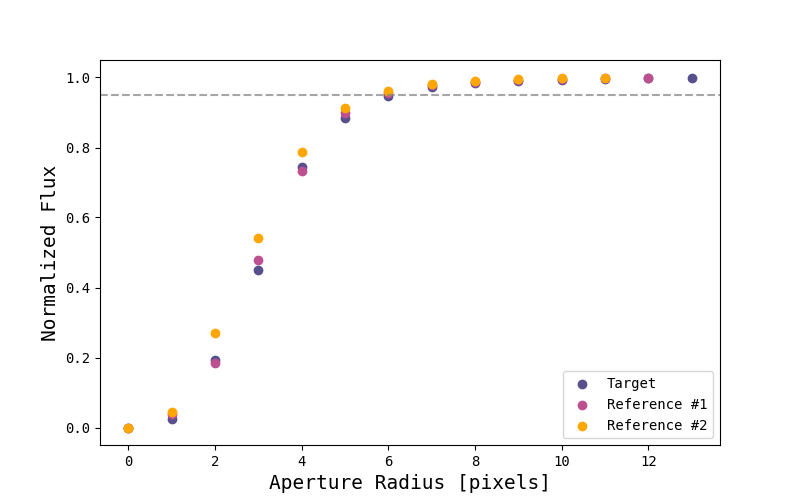

In [8]:
# Calculate and plot for Target
plt.figure(figsize=(8, 5))

target_radius_array = np.arange(0, target_inner_radius + 1., 1.0)  # Increased step size to 2.0
target_total_flux = np.sum(target_science_sky_corrected[target_distance < target_inner_radius])
target_flux_vs_radius = [
    np.sum(target_science_sky_corrected[target_distance < radius]) / target_total_flux
    for radius in target_radius_array
]
plt.scatter(target_radius_array, target_flux_vs_radius, label="Target", color="#58508d")

# Calculate and plot for Reference #1
ref01_radius_array = np.arange(0, reference_01_inner_radius + 1., 1.0)  # Increased step size to 2.0
ref01_total_flux = np.sum(reference_01_science_sky_corrected[reference_01_distance < reference_01_inner_radius])
ref01_flux_vs_radius = [
    np.sum(reference_01_science_sky_corrected[reference_01_distance < radius]) / ref01_total_flux
    for radius in ref01_radius_array
]
plt.scatter(ref01_radius_array, ref01_flux_vs_radius, label="Reference #1", color="#bc5090")

# Calculate and plot for Reference #2
ref02_radius_array = np.arange(0, reference_02_inner_radius + 1., 1.0)  # Increased step size to 2.0
ref02_total_flux = np.sum(reference_02_science_sky_corrected[reference_02_distance < reference_02_inner_radius])
ref02_flux_vs_radius = [
    np.sum(reference_02_science_sky_corrected[reference_02_distance < radius]) / ref02_total_flux
    for radius in ref02_radius_array
]
plt.scatter(ref02_radius_array, ref02_flux_vs_radius, label="Reference #2", color="#ffa600")

# Add a horizontal line at 0.95
plt.axhline(0.95, color="gray", linestyle="--", alpha=0.7)

# Customize the plot
plt.xlabel("Aperture Radius [pixels]")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

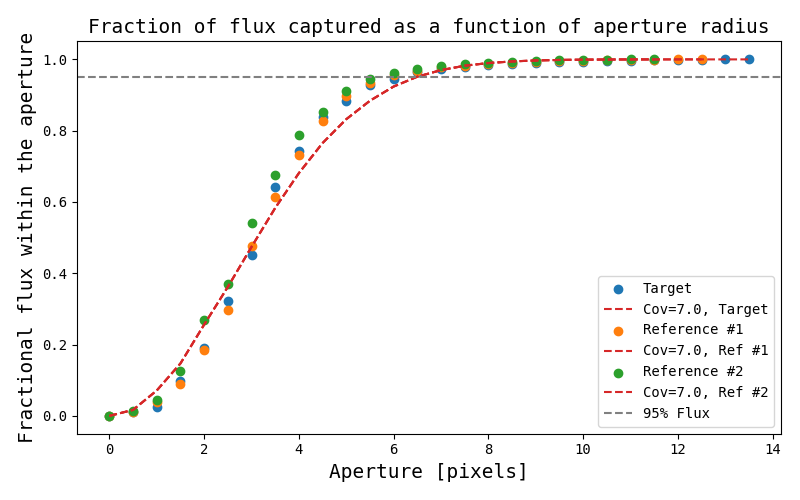

In [9]:
from scipy.stats import multivariate_normal

# Define covariance values and their colors
cov_values = [7.]
cov_colors = ["C3"]

plt.figure(figsize=(8, 5))

# Calculate and plot for Target
target_radius_array = np.arange(0, target_inner_radius + 1., 0.5)
target_total_flux = np.sum(target_science_sky_corrected[target_distance < target_inner_radius])
target_flux_vs_radius = [
    np.sum(target_science_sky_corrected[target_distance < radius]) / target_total_flux
    for radius in target_radius_array
]
plt.scatter(target_radius_array, target_flux_vs_radius, label="Target", color="C0")

# Add Gaussian covariance models for Target
xy_range = np.arange(-target_inner_radius * 1.2, target_inner_radius * 1.2, 0.5)
X_gauss, Y_gauss = np.meshgrid(xy_range, xy_range)
gauss_distance = np.sqrt(X_gauss**2 + Y_gauss**2)
pos = np.dstack((X_gauss, Y_gauss))

for cov, color in zip(cov_values, cov_colors):
    cov_matrix = [[cov, 0], [0, cov]]
    mv_normal = multivariate_normal(mean=[0., 0.], cov=cov_matrix)
    mv_normal_pdf = mv_normal.pdf(pos)
    mv_normal_pdf /= mv_normal_pdf.max()  # Normalize the PDF

    gaussian_flux = [
        np.sum(mv_normal_pdf[gauss_distance < radius])
        for radius in target_radius_array
    ]
    gaussian_flux /= max(gaussian_flux)  # Normalize flux
    plt.plot(target_radius_array, gaussian_flux, label=f"Cov={cov}, Target", linestyle="--", color=color)

# Repeat for Reference #1
ref01_radius_array = np.arange(0, reference_01_inner_radius + 1., 0.5)
ref01_total_flux = np.sum(reference_01_science_sky_corrected[reference_01_distance < reference_01_inner_radius])
ref01_flux_vs_radius = [
    np.sum(reference_01_science_sky_corrected[reference_01_distance < radius]) / ref01_total_flux
    for radius in ref01_radius_array
]
plt.scatter(ref01_radius_array, ref01_flux_vs_radius, label="Reference #1", color="C1")

for cov, color in zip(cov_values, cov_colors):
    cov_matrix = [[cov, 0], [0, cov]]
    mv_normal = multivariate_normal(mean=[0., 0.], cov=cov_matrix)
    mv_normal_pdf = mv_normal.pdf(pos)
    mv_normal_pdf /= mv_normal_pdf.max()  # Normalize the PDF

    gaussian_flux = [
        np.sum(mv_normal_pdf[gauss_distance < radius])
        for radius in ref01_radius_array
    ]
    gaussian_flux /= max(gaussian_flux)  # Normalize flux
    plt.plot(ref01_radius_array, gaussian_flux, label=f"Cov={cov}, Ref #1", linestyle="--", color=color)

# Repeat for Reference #2
ref02_radius_array = np.arange(0, reference_02_inner_radius + 1., 0.5)
ref02_total_flux = np.sum(reference_02_science_sky_corrected[reference_02_distance < reference_02_inner_radius])
ref02_flux_vs_radius = [
    np.sum(reference_02_science_sky_corrected[reference_02_distance < radius]) / ref02_total_flux
    for radius in ref02_radius_array
]
plt.scatter(ref02_radius_array, ref02_flux_vs_radius, label="Reference #2", color="C2")

for cov, color in zip(cov_values, cov_colors):
    cov_matrix = [[cov, 0], [0, cov]]
    mv_normal = multivariate_normal(mean=[0., 0.], cov=cov_matrix)
    mv_normal_pdf = mv_normal.pdf(pos)
    mv_normal_pdf /= mv_normal_pdf.max()  # Normalize the PDF

    gaussian_flux = [
        np.sum(mv_normal_pdf[gauss_distance < radius])
        for radius in ref02_radius_array
    ]
    gaussian_flux /= max(gaussian_flux)  # Normalize flux
    plt.plot(ref02_radius_array, gaussian_flux, label=f"Cov={cov}, Ref #2", linestyle="--", color=color)

# Add a horizontal line at 0.95
plt.axhline(0.95, color="gray", linestyle="--", label="95% Flux")

# Customize the plot
plt.xlabel("Aperture [pixels]")
plt.ylabel("Fractional flux within the aperture")
plt.title("Fraction of flux captured as a function of aperture radius")
plt.legend()
plt.tight_layout()
plt.show()
